# Slum Classification — Sentinel-2 DKI Jakarta (eksp2)

**Reformulasi:** segmentasi piksel → **klasifikasi biner level-RW** (1 citra TIF = 1 sampel, slum=1 / non-slum=0).

Alasan: label aslinya poligon per-RW (area), bukan batas kumuh per-piksel. Klasifikasi cocok dengan cara label dibuat, hemat data (400 sampel layak), training cepat, skor jujur.

Pipeline: Bangun tabel sampel → Feature engineering → Baseline Classical (XGBoost/RF) → Baseline CNN → Evaluasi seragam (Spatial GroupKFold per-kecamatan) → Interpretasi.

Evaluasi memakai **GroupKFold per-kecamatan** (pertahankan praktik anti spatial-leakage dari notebook lama), class imbalance ditangani via class weight, threshold di-tune (maksimalkan F1), metrik: F1 / precision / recall / ROC-AUC / PR-AUC / confusion matrix.

## 0. Dependencies

Wajib: `numpy pandas matplotlib geopandas rasterio scikit-learn torch tqdm`
Opsional (ada fallback otomatis bila tak terpasang): `xgboost` (→ fallback RandomForest), `scikit-image` (→ fallback tekstur gradien).

```
pip install numpy pandas matplotlib geopandas rasterio scikit-learn torch tqdm xgboost scikit-image
```

Catatan: jalankan dari folder notebook yang sejajar dengan `../dataset` (struktur sama seperti notebook lama). Hasil fitur & citra ter-resize di-cache di `../dataset/cache_cls/` agar run berikutnya cepat.

In [1]:
%matplotlib inline
import os, re, time, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, accuracy_score,
    confusion_matrix, precision_recall_curve, roc_curve)
from tqdm import tqdm

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# Band order: B2=0, B3=1, B4=2, B8=3, B11=4, B12=5
DATA_DIR   = Path('../dataset')
SLUM_DIR   = DATA_DIR / 'images' / 'slum'
NSLUM_DIR  = DATA_DIR / 'images' / 'non_slum'
CACHE_DIR  = DATA_DIR / 'cache_cls'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
N_SPLITS   = 5
BAND_NAMES = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']

print('Data dir :', DATA_DIR.resolve())
print('Cache dir:', CACHE_DIR.resolve())

Data dir : E:\competition\Hackathon-ML\dataset
Cache dir: E:\competition\Hackathon-ML\dataset\cache_cls


## 1. Bangun Tabel Sampel

Setiap TIF = 1 sampel. Label dari folder (slum/non_slum), kecamatan dari GeoJSON via FID (`_ID<n>.tif`). Kecamatan dipakai sebagai *group* untuk spatial CV.

In [2]:
def extract_fid(filename):
    m = re.search(r'_ID(\d+)\.tif$', filename)
    return int(m.group(1)) if m else None

gdf_slum  = gpd.read_file(DATA_DIR / 'labels' / 'dki_slum.geojson')
gdf_nslum = gpd.read_file(DATA_DIR / 'labels' / 'dki_non_slum.geojson')

slum_kec  = dict(zip(gdf_slum['FID'],  gdf_slum['KEC_NAME'].astype(str).str.upper().str.strip()))
nslum_kec = dict(zip(gdf_nslum['FID'], gdf_nslum['Kecamatan'].astype(str).str.upper().str.strip()))

rows = []
for f in sorted(SLUM_DIR.glob('*.tif')):
    fid = extract_fid(f.name)
    rows.append({'path': str(f), 'name': f.name, 'label': 1,
                 'fid': fid, 'kecamatan': slum_kec.get(fid, 'UNKNOWN')})
for f in sorted(NSLUM_DIR.glob('*.tif')):
    fid = extract_fid(f.name)
    rows.append({'path': str(f), 'name': f.name, 'label': 0,
                 'fid': fid, 'kecamatan': nslum_kec.get(fid, 'UNKNOWN')})

samples = pd.DataFrame(rows)
print('Total sampel    :', len(samples))
print(samples['label'].map({1: 'slum', 0: 'non_slum'}).value_counts().to_string())
print('Kecamatan unik  :', samples['kecamatan'].nunique())
print('UNKNOWN kecamatan:', int((samples['kecamatan'] == 'UNKNOWN').sum()))
samples.head()

Total sampel    : 401
label
non_slum    261
slum        140
Kecamatan unik  : 42
UNKNOWN kecamatan: 0


,path,name,label,fid,kecamatan
0,..\dataset\images\slum\SLUM_ANCOL_RW_01_ID86.tif,SLUM_ANCOL_RW_01_ID86.tif,1,86,PADEMANGAN
1,..\dataset\images\slum\SLUM_ANCOL_RW_02_ID87.tif,SLUM_ANCOL_RW_02_ID87.tif,1,87,PADEMANGAN
2,..\dataset\images\slum\SLUM_ANCOL_RW_04_ID88.tif,SLUM_ANCOL_RW_04_ID88.tif,1,88,PADEMANGAN
3,..\dataset\images\slum\SLUM_ANCOL_RW_05_ID89.tif,SLUM_ANCOL_RW_05_ID89.tif,1,89,PADEMANGAN
4,..\dataset\images\slum\SLUM_ANCOL_RW_08_ID90.tif,SLUM_ANCOL_RW_08_ID90.tif,1,90,PADEMANGAN


## 2. Feature Engineering (jalur Classical)

Per citra: statistik per-band (mean/std/min/max/percentile), indeks spektral (NDVI, NDBI, MNDWI, NDWI, BSI), tekstur GLCM pada NDBI (kepadatan/keteraturan bangunan), serta ukuran. Piksel nodata (semua band = 0) diabaikan.

Catatan: fitur ukuran (`height/width/n_valid/aspect_ratio`) tersedia saat inferensi (extent RW), tapi bisa mencerminkan artefak konstruksi dataset. Setel `USE_SIZE_FEATURES=False` di sel baseline untuk mengujinya tanpa fitur ukuran.

In [3]:
try:
    from skimage.feature import graycomatrix, graycoprops
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False
    print('skimage tidak tersedia -> fallback tekstur berbasis gradien')

PCTS = [10, 25, 50, 75, 90]

def safe_idx(a, b):
    d = a + b
    return np.where(d == 0, 0.0, (a - b) / d)

def stat_block(values, prefix, out):
    if values.size == 0:
        values = np.array([0.0], dtype=np.float32)
    out[prefix + '_mean'] = float(values.mean())
    out[prefix + '_std']  = float(values.std())
    out[prefix + '_min']  = float(values.min())
    out[prefix + '_max']  = float(values.max())
    for p, val in zip(PCTS, np.percentile(values, PCTS)):
        out[prefix + '_p' + str(p)] = float(val)

def glcm_feats(gray_u8, mask, out, prefix='NDBI'):
    if HAS_SKIMAGE and mask.sum() > 16:
        g = graycomatrix(gray_u8, distances=[1],
                         angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                         levels=32, symmetric=True, normed=True)
        for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']:
            out['tex_' + prefix + '_' + prop] = float(graycoprops(g, prop).mean())
    else:
        gy, gx = np.gradient(gray_u8.astype(np.float32))
        gm = np.sqrt(gx**2 + gy**2)[mask]
        out['tex_grad_mean'] = float(gm.mean()) if gm.size else 0.0
        out['tex_grad_std']  = float(gm.std())  if gm.size else 0.0

def compute_features(path):
    with rasterio.open(path) as src:
        arr = src.read().astype(np.float32)   # (6, H, W)
        H, W = src.height, src.width
    valid = np.any(arr != 0, axis=0)
    B2, B3, B4, B8, B11, B12 = arr
    out = {}
    for name, b in zip(BAND_NAMES, arr):
        stat_block(b[valid], name, out)
    idxs = {'NDVI': safe_idx(B8, B4), 'NDBI': safe_idx(B11, B8),
            'MNDWI': safe_idx(B3, B11), 'NDWI': safe_idx(B3, B8),
            'BSI': safe_idx(B11 + B4, B8 + B2)}
    for name, ix in idxs.items():
        stat_block(ix[valid], name, out)
    q = np.clip((idxs['NDBI'] + 1) / 2 * 31, 0, 31).astype(np.uint8)
    q[~valid] = 0
    glcm_feats(q, valid, out, 'NDBI')
    out['height'] = H
    out['width'] = W
    out['n_valid'] = int(valid.sum())
    out['valid_ratio'] = float(valid.mean())
    out['aspect_ratio'] = float(W / H) if H > 0 else 0.0
    return out

feat_cache = CACHE_DIR / 'features.csv'
feat_df = None
if feat_cache.exists():
    feat_df = pd.read_csv(feat_cache)
    if 'path' not in feat_df.columns:        # cache lama tanpa kunci unik -> hitung ulang
        feat_df = None
    else:
        print('Loaded cached features:', feat_df.shape)
if feat_df is None:
    recs = []
    for _, r in tqdm(samples.iterrows(), total=len(samples), desc='Features'):
        f = compute_features(r['path'])
        f['path'] = r['path']        # kunci unik untuk merge (bukan nama file)
        f['name'] = r['name']
        recs.append(f)
    feat_df = pd.DataFrame(recs)
    feat_df.to_csv(feat_cache, index=False)
    print('Computed features:', feat_df.shape)

# Merge pada 'path' (unik), bukan 'name', lalu pastikan alignment baris.
data = samples.merge(feat_df.drop(columns=['name']), on='path', validate='one_to_one')
data = data.reset_index(drop=True)
assert len(data) == len(samples), 'Jumlah baris berubah setelah merge — cek cache/feature'
assert data['path'].is_unique, 'Ada path duplikat setelah merge'

FEATURE_COLS = [c for c in feat_df.columns if c not in ('name', 'path')]
y = data['label'].values
groups = data['kecamatan'].values
print('Jumlah fitur:', len(FEATURE_COLS), '| baris selaras:', len(data) == len(samples))

Loaded cached features: (401, 108)
Jumlah fitur: 106 | baris selaras: True


In [4]:
gkf = GroupKFold(n_splits=N_SPLITS)
folds = list(gkf.split(data, y, groups=groups))
for i, (tr, va) in enumerate(folds):
    print('Fold %d: train %3d | val %3d | val slum %2d/%-3d | n_kec_val %d'
          % (i + 1, len(tr), len(va), int(y[va].sum()), len(va), len(set(groups[va]))))

Fold 1: train 322 | val  79 | val slum 29/79  | n_kec_val 8
Fold 2: train 322 | val  79 | val slum 30/79  | n_kec_val 8
Fold 3: train 322 | val  79 | val slum 26/79  | n_kec_val 8
Fold 4: train 318 | val  83 | val slum 29/83  | n_kec_val 9
Fold 5: train 320 | val  81 | val slum 26/81  | n_kec_val 9


## 3. Util Metrik & Threshold

**ROC-AUC / PR-AUC adalah metrik utama** karena threshold-independent. Threshold global di-tune sekali pada prediksi out-of-fold (OOF) dengan memaksimalkan F1, lalu dipakai untuk semua fold. Catatan kejujuran: F1/precision/recall pada threshold hasil tuning OOF sedikit optimistik (threshold dipilih dengan melihat label evaluasi); untuk pelaporan ketat gunakan kalibrasi nested-CV atau holdout terpisah. Untuk baseline hackathon ini, AUC/AP-lah angka yang paling dapat dipercaya.

In [5]:
def best_threshold(y_true, y_prob):
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    if len(thr) == 0:
        return 0.5
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    return float(thr[int(np.argmax(f1))])

def compute_metrics(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    multi = len(set(y_true)) > 1
    return {
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'ROC_AUC':   roc_auc_score(y_true, y_prob) if multi else float('nan'),
        'PR_AUC':    average_precision_score(y_true, y_prob) if multi else float('nan'),
        'accuracy':  accuracy_score(y_true, y_pred),
        'threshold': thr,
    }

def summarize(results, name):
    df = pd.DataFrame(results)
    print('\n=== %s -- per fold ===' % name)
    print(df[['fold', 'F1', 'precision', 'recall', 'ROC_AUC', 'PR_AUC', 'accuracy']].to_string(index=False))
    print('\n=== %s -- mean +/- std ===' % name)
    for m in ['F1', 'precision', 'recall', 'ROC_AUC', 'PR_AUC', 'accuracy']:
        print('%-10s: %.4f +/- %.4f' % (m, df[m].mean(), df[m].std()))
    return df

## 4. Baseline Classical (XGBoost / RandomForest)

Class imbalance ditangani via `scale_pos_weight` (XGB) atau `class_weight='balanced'` (RF). Fitur distandardisasi per-fold (fit di train saja). Feature importance dirata-rata antar fold.

In [6]:
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False
    from sklearn.ensemble import RandomForestClassifier
    print('xgboost tidak tersedia -> fallback RandomForest')

USE_SIZE_FEATURES = True
SIZE_COLS = ['height', 'width', 'n_valid', 'aspect_ratio']
cols = FEATURE_COLS if USE_SIZE_FEATURES else [c for c in FEATURE_COLS if c not in SIZE_COLS]
X = np.nan_to_num(data[cols].values.astype(np.float32))

oof_prob = np.zeros(len(data))
importances = np.zeros(len(cols))
fold_store = []

for fold_i, (tr, va) in enumerate(folds):
    sc = StandardScaler().fit(X[tr])
    Xtr, Xva = sc.transform(X[tr]), sc.transform(X[va])
    n_pos = int(y[tr].sum()); n_neg = len(tr) - n_pos
    if HAS_XGB:
        model = XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              scale_pos_weight=n_neg / max(n_pos, 1),
                              eval_metric='logloss', random_state=SEED, n_jobs=-1)
    else:
        model = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                       random_state=SEED, n_jobs=-1)
    model.fit(Xtr, y[tr])
    oof_prob[va] = model.predict_proba(Xva)[:, 1]
    importances += model.feature_importances_ / N_SPLITS
    fold_store.append((fold_i + 1, va))

GLOBAL_THR_CLF = best_threshold(y, oof_prob)
clf_results = [dict(compute_metrics(y[va], oof_prob[va], GLOBAL_THR_CLF), fold=fi) for fi, va in fold_store]
clf_df = summarize(clf_results, 'Classical (XGB/RF)')
print('\nGlobal threshold (Classical): %.3f' % GLOBAL_THR_CLF)


=== Classical (XGB/RF) -- per fold ===
 fold       F1  precision   recall  ROC_AUC   PR_AUC  accuracy
    1 0.791667   1.000000 0.655172 0.895862 0.880098  0.873418
    2 0.949153   0.965517 0.933333 0.991156 0.986762  0.962025
    3 0.962963   0.928571 1.000000 0.997823 0.995558  0.974684
    4 0.816327   1.000000 0.689655 0.979566 0.966525  0.891566
    5 0.888889   0.857143 0.923077 0.983916 0.978456  0.925926

=== Classical (XGB/RF) -- mean +/- std ===
F1        : 0.8818 +/- 0.0768
precision : 0.9502 +/- 0.0598
recall    : 0.8402 +/- 0.1565
ROC_AUC   : 0.9697 +/- 0.0418
PR_AUC    : 0.9615 +/- 0.0467
accuracy  : 0.9255 +/- 0.0436

Global threshold (Classical): 0.769


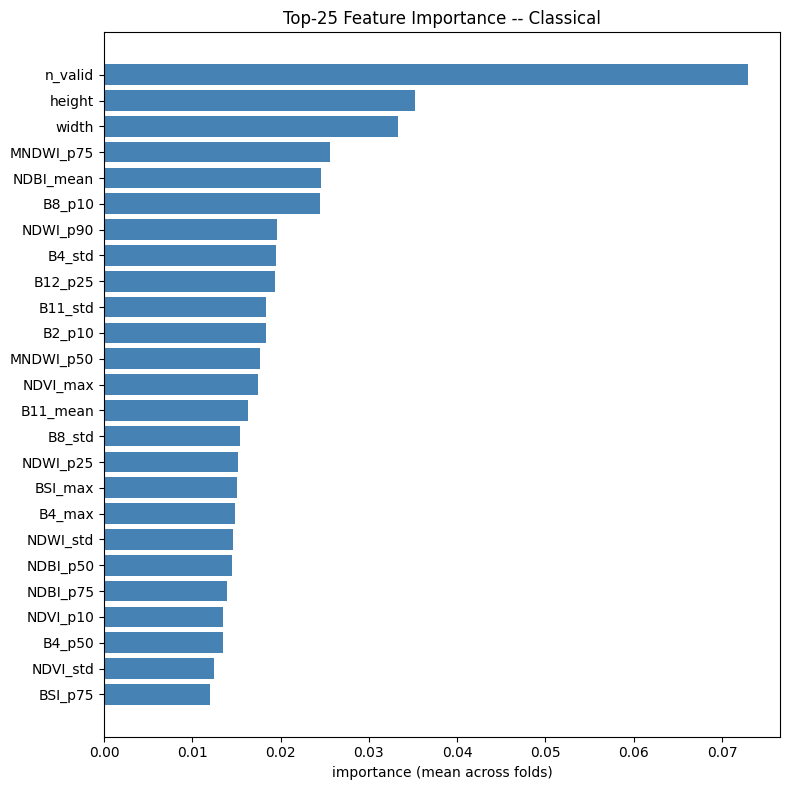

n_valid      0.072927
height       0.035252
width        0.033254
MNDWI_p75    0.025629
NDBI_mean    0.024634
B8_p10       0.024487
NDWI_p90     0.019639
B4_std       0.019471
B12_p25      0.019418
B11_std      0.018389
B2_p10       0.018341
MNDWI_p50    0.017703
NDVI_max     0.017419
B11_mean     0.016294
B8_std       0.015464


In [7]:
imp = pd.Series(importances, index=cols).sort_values(ascending=False)
top = imp.head(25)
plt.figure(figsize=(8, 8))
plt.barh(top.index[::-1], top.values[::-1], color='steelblue')
plt.title('Top-25 Feature Importance -- Classical')
plt.xlabel('importance (mean across folds)')
plt.tight_layout(); plt.show()
print(imp.head(15).to_string())

## 5. Baseline CNN (multi-band)

Citra di-resize ke ukuran tetap (9 channel: 6 band + NDVI/NDBI/MNDWI), dinormalisasi per-channel dari train fold saja. CNN kecil + global average pooling. Imbalance via `pos_weight` di BCE. Kecepatan: cache RAM, `num_workers`, mixed precision (AMP), early stopping pada AUC.

Ubah `IMG` (default 96) bila ingin lebih cepat (64) atau lebih detail (128).

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', DEVICE, '| PyTorch:', torch.__version__)
if DEVICE.type != 'cuda':
    print('PERINGATAN: CUDA tidak terdeteksi -> CNN jalan di CPU (sangat lambat, bisa 1-2 jam).')
    print('          Cek: torch.cuda.is_available(); install torch build CUDA bila punya GPU.')
# Windows + Jupyter: num_workers=0 lebih cepat & stabil (data sudah di-cache RAM)
NUM_WORKERS = 0 if os.name == 'nt' else 2
print('num_workers:', NUM_WORKERS)
IMG = 96

def load_image_9ch(path):
    with rasterio.open(path) as src:
        arr = src.read().astype(np.float32)
    B2, B3, B4, B8, B11, B12 = arr
    ndvi = safe_idx(B8, B4); ndbi = safe_idx(B11, B8); mndwi = safe_idx(B3, B11)
    x = np.concatenate([arr, ndvi[None], ndbi[None], mndwi[None]], axis=0)
    t = torch.from_numpy(x).unsqueeze(0)
    t = torch.nn.functional.interpolate(t, size=(IMG, IMG), mode='bilinear', align_corners=False)
    return t.squeeze(0).numpy().astype(np.float32)

img_cache = CACHE_DIR / ('imgs_%d.npy' % IMG)
if img_cache.exists():
    X_img = np.load(img_cache)
    print('Loaded cached images:', X_img.shape)
else:
    X_img = np.zeros((len(data), 9, IMG, IMG), dtype=np.float32)
    for i, p in enumerate(tqdm(data['path'].values, desc='Load+resize')):
        X_img[i] = load_image_9ch(p)
    np.save(img_cache, X_img)
    print('Cached images:', X_img.shape)

Device : cuda | PyTorch: 2.6.0+cu124
num_workers: 0
Loaded cached images: (401, 9, 96, 96)


In [9]:
class ImgDataset(Dataset):
    def __init__(self, X, yy, mean, std, augment=False):
        self.X = X; self.y = yy; self.mean = mean; self.std = std; self.augment = augment
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        x = (self.X[i] - self.mean) / self.std
        if self.augment:
            if np.random.rand() > 0.5: x = np.flip(x, 2).copy()
            if np.random.rand() > 0.5: x = np.flip(x, 1).copy()
            k = np.random.randint(0, 4)
            if k: x = np.rot90(x, k, axes=(1, 2)).copy()
        return torch.from_numpy(x).float(), torch.tensor(self.y[i], dtype=torch.float32)

class SmallCNN(nn.Module):
    def __init__(self, in_ch=9):
        super().__init__()
        def blk(i, o):
            return nn.Sequential(
                nn.Conv2d(i, o, 3, padding=1, bias=False), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                nn.Conv2d(o, o, 3, padding=1, bias=False), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                nn.MaxPool2d(2))
        self.f = nn.Sequential(blk(in_ch, 32), blk(32, 64), blk(64, 128), blk(128, 256))
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.4), nn.Linear(256, 1))
    def forward(self, x):
        return self.head(self.f(x)).squeeze(1)

def train_cnn_fold(tr, va, epochs=60, batch=16, lr=1e-3, patience=12):
    mean = X_img[tr].mean(axis=(0, 2, 3), keepdims=True)[0]
    std  = X_img[tr].std(axis=(0, 2, 3), keepdims=True)[0] + 1e-6
    tl = DataLoader(ImgDataset(X_img[tr], y[tr], mean, std, augment=True),
                    batch_size=batch, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True,
                    persistent_workers=(NUM_WORKERS > 0))
    vl = DataLoader(ImgDataset(X_img[va], y[va], mean, std, augment=False),
                    batch_size=batch, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True,
                    persistent_workers=(NUM_WORKERS > 0))
    model = SmallCNN().to(DEVICE)
    n_pos = int(y[tr].sum()); n_neg = len(tr) - n_pos
    crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([n_neg / max(n_pos, 1)], device=DEVICE))
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    use_amp = (DEVICE.type == 'cuda')
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    best_auc, best_prob, bad = -1.0, None, 0
    for ep in range(epochs):
        model.train()
        for xb, yb in tl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            with torch.amp.autocast('cuda', enabled=use_amp):
                loss = crit(model(xb), yb)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        model.eval(); probs = []
        with torch.no_grad():
            for xb, yb in vl:
                with torch.amp.autocast('cuda', enabled=use_amp):
                    p = torch.sigmoid(model(xb.to(DEVICE)))
                probs.append(p.float().cpu().numpy())
        prob = np.concatenate(probs)
        auc = roc_auc_score(y[va], prob) if len(set(y[va])) > 1 else 0.5
        sched.step(1 - auc)
        if auc > best_auc:
            best_auc, best_prob, bad = auc, prob, 0
        else:
            bad += 1
            if bad >= patience:
                break
    return best_prob

In [10]:
def safe_auc(yt, p):
    return roc_auc_score(yt, p) if len(set(yt)) > 1 else float('nan')

oof_prob_cnn = np.zeros(len(data))
cnn_store = []
t0 = time.time()
for fold_i, (tr, va) in enumerate(folds):
    prob = train_cnn_fold(tr, va)
    oof_prob_cnn[va] = prob
    cnn_store.append((fold_i + 1, va))
    print('Fold %d done | AUC=%.4f | %.0fs elapsed'
          % (fold_i + 1, safe_auc(y[va], prob), time.time() - t0))

GLOBAL_THR_CNN = best_threshold(y, oof_prob_cnn)
cnn_results = [dict(compute_metrics(y[va], oof_prob_cnn[va], GLOBAL_THR_CNN), fold=fi) for fi, va in cnn_store]
cnn_df = summarize(cnn_results, 'CNN')
print('\nGlobal threshold (CNN): %.3f' % GLOBAL_THR_CNN)

Fold 1 done | AUC=0.9931 | 49s elapsed
Fold 2 done | AUC=1.0000 | 72s elapsed
Fold 3 done | AUC=0.9989 | 84s elapsed
Fold 4 done | AUC=0.9943 | 114s elapsed
Fold 5 done | AUC=1.0000 | 134s elapsed

=== CNN -- per fold ===
 fold       F1  precision   recall  ROC_AUC   PR_AUC  accuracy
    1 0.884615   1.000000 0.793103 0.993103 0.989597  0.924051
    2 1.000000   1.000000 1.000000 1.000000 1.000000  1.000000
    3 0.896552   0.812500 1.000000 0.998911 0.997096  0.924051
    4 0.949153   0.933333 0.965517 0.994253 0.990996  0.963855
    5 1.000000   1.000000 1.000000 1.000000 1.000000  1.000000

=== CNN -- mean +/- std ===
F1        : 0.9461 +/- 0.0549
precision : 0.9492 +/- 0.0817
recall    : 0.9517 +/- 0.0899
ROC_AUC   : 0.9973 +/- 0.0033
PR_AUC    : 0.9955 +/- 0.0050
accuracy  : 0.9624 +/- 0.0380

Global threshold (CNN): 0.695


## 6. Perbandingan & Interpretasi

=== Ringkasan (mean across folds) ===
    model       F1  precision   recall  ROC_AUC   PR_AUC  accuracy
Classical 0.881800   0.950246 0.840248 0.969665 0.961480  0.925524
      CNN 0.946064   0.949167 0.951724 0.997254 0.995538  0.962391


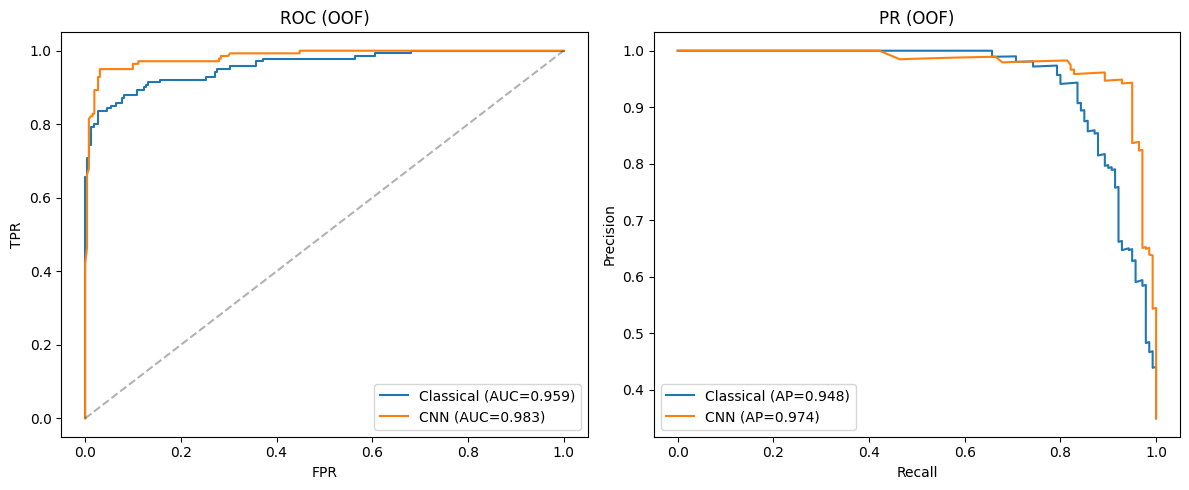

In [11]:
def mean_row(df, name):
    return dict(model=name, **{m: df[m].mean() for m in
               ['F1', 'precision', 'recall', 'ROC_AUC', 'PR_AUC', 'accuracy']})

cmp = pd.DataFrame([mean_row(clf_df, 'Classical'), mean_row(cnn_df, 'CNN')])
print('=== Ringkasan (mean across folds) ===')
print(cmp.to_string(index=False))

fig, (a, b) = plt.subplots(1, 2, figsize=(12, 5))
for prob, name in [(oof_prob, 'Classical'), (oof_prob_cnn, 'CNN')]:
    fpr, tpr, _ = roc_curve(y, prob)
    a.plot(fpr, tpr, label='%s (AUC=%.3f)' % (name, roc_auc_score(y, prob)))
    pr, rc, _ = precision_recall_curve(y, prob)
    b.plot(rc, pr, label='%s (AP=%.3f)' % (name, average_precision_score(y, prob)))
a.plot([0, 1], [0, 1], 'k--', alpha=0.3)
a.set_xlabel('FPR'); a.set_ylabel('TPR'); a.set_title('ROC (OOF)'); a.legend()
b.set_xlabel('Recall'); b.set_ylabel('Precision'); b.set_title('PR (OOF)'); b.legend()
plt.tight_layout(); plt.show()

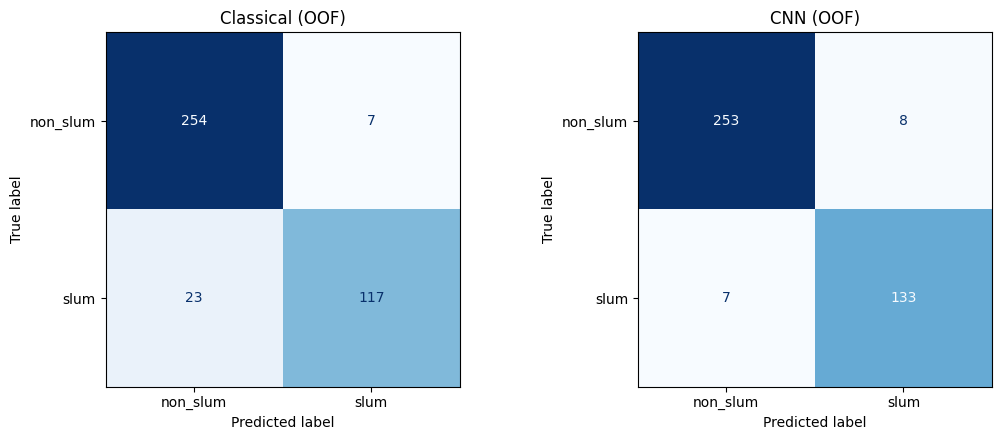

Model terbaik (OOF): CNN

=== Akurasi OOF per-kecamatan ===
                    n  n_slum       acc
kecamatan                              
KELAPA GADING       6       3  0.666667
SETIA BUDI         11       3  0.727273
CENGKARENG          6       0  0.833333
GROGOL PETAMBURAN   7       0  0.857143
CILINCING          23      16  0.869565
KEBAYORAN BARU     19       9  0.894737
PASAR MINGGU       10       3  0.900000
PADEMANGAN         12       9  0.916667
TANAH ABANG        19      12  0.947368
CIRACAS             5       0  1.000000
DUREN SAWIT         7       0  1.000000
GAMBIR              8       2  1.000000
JATINEGARA          8       0  1.000000
CIPAYUNG            8       0  1.000000
JAGAKARSA           6       0  1.000000
CILANDAK            7       2  1.000000
KEBAYORAN LAMA     10       4  1.000000
KALIDERES           5       0  1.000000
JOHAR BARU         15      11  1.000000
KEBON JERUK         7       0  1.000000
KOJA               13       7  1.000000
KRAMAT JATI         

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (prob, thr, name) in zip(axes,
        [(oof_prob, GLOBAL_THR_CLF, 'Classical'), (oof_prob_cnn, GLOBAL_THR_CNN, 'CNN')]):
    cm = confusion_matrix(y, (prob >= thr).astype(int))
    ConfusionMatrixDisplay(cm, display_labels=['non_slum', 'slum']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title('%s (OOF)' % name)
plt.tight_layout(); plt.show()

best_name = 'Classical' if clf_df['F1'].mean() >= cnn_df['F1'].mean() else 'CNN'
best_prob = oof_prob if best_name == 'Classical' else oof_prob_cnn
best_thr  = GLOBAL_THR_CLF if best_name == 'Classical' else GLOBAL_THR_CNN
data['oof_prob'] = best_prob
data['oof_pred'] = (best_prob >= best_thr).astype(int)
data['correct']  = (data['oof_pred'] == data['label']).astype(int)
print('Model terbaik (OOF):', best_name)

kec = (data.groupby('kecamatan')
            .agg(n=('label', 'size'), n_slum=('label', 'sum'), acc=('correct', 'mean'))
            .sort_values('acc'))
print('\n=== Akurasi OOF per-kecamatan ===')
print(kec.to_string())

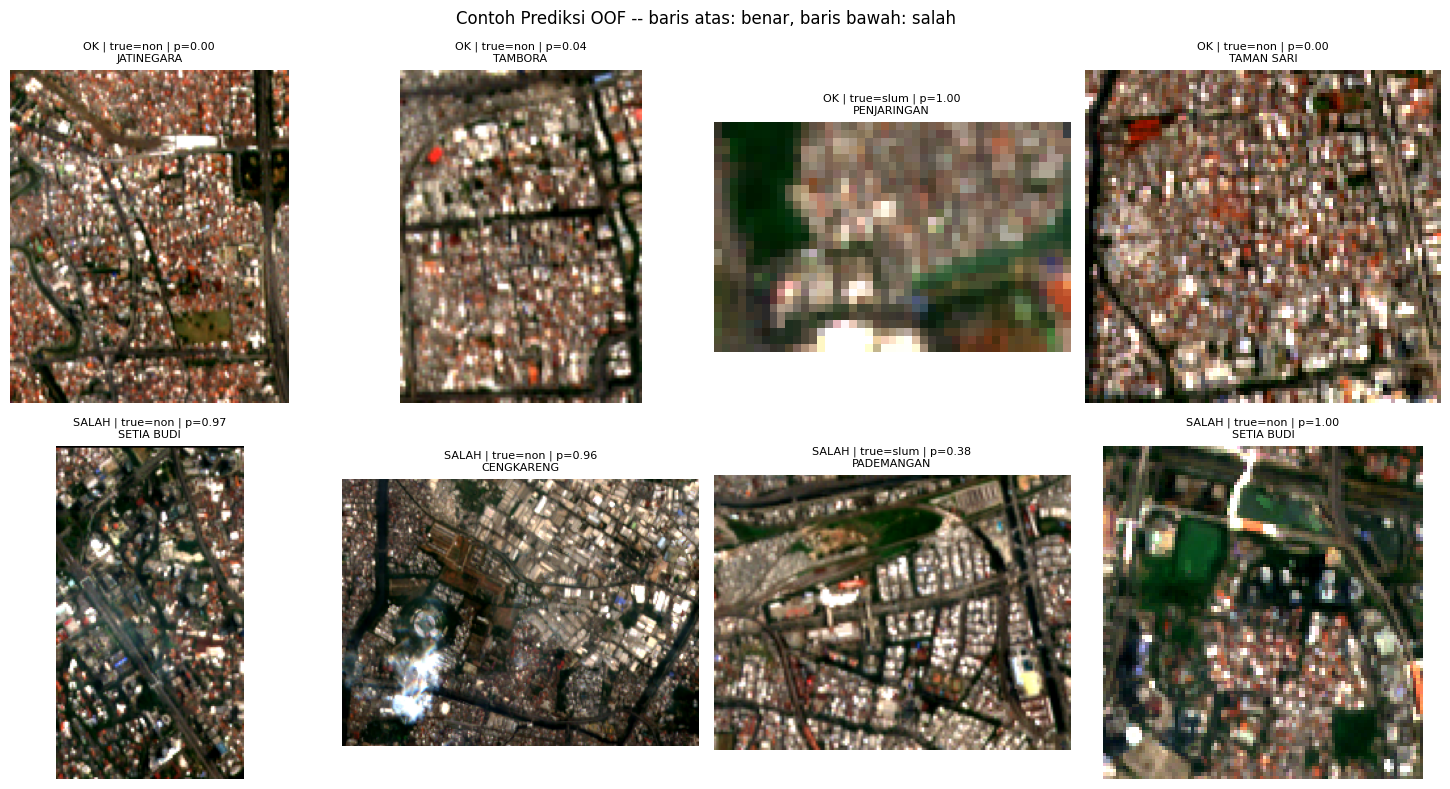

In [13]:
def rgb_stretch(arr6):
    rgb = arr6[[2, 1, 0]].copy()
    v = rgb[rgb > 0]
    if v.size == 0:
        return np.zeros((rgb.shape[1], rgb.shape[2], 3))
    p2, p98 = np.percentile(v, (2, 98))
    rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-8), 0, 1)
    return rgb.transpose(1, 2, 0)

n_wrong = int((data['correct'] == 0).sum())
right = data[data['correct'] == 1].sample(min(4, int((data['correct'] == 1).sum())), random_state=SEED)
wrong = data[data['correct'] == 0].sample(min(4, n_wrong), random_state=SEED) if n_wrong else data.iloc[0:0]
show = pd.concat([right, wrong])

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for ax, (_, r) in zip(axes.ravel(), show.iterrows()):
    with rasterio.open(r['path']) as src:
        a = src.read().astype(np.float32)
    ax.imshow(rgb_stretch(a))
    tag = 'OK' if r['correct'] else 'SALAH'
    ax.set_title('%s | true=%s | p=%.2f\n%s'
                 % (tag, 'slum' if r['label'] else 'non', r['oof_prob'], r['kecamatan']), fontsize=8)
    ax.axis('off')
for ax in axes.ravel()[len(show):]:
    ax.axis('off')
plt.suptitle('Contoh Prediksi OOF -- baris atas: benar, baris bawah: salah')
plt.tight_layout(); plt.show()

## 7. Ringkasan & Langkah Lanjut

**Perubahan kunci vs notebook lama (segmentasi):**
- Tugas: segmentasi piksel (label area lemah, model kolaps ke 0, IoU ~0.22) → **klasifikasi biner per-RW**, selaras dengan label.
- Imbalance: dari 1.67% piksel positif (BCE didominasi nol) → imbalance level-sampel 140:261 ditangani via class weight.
- Kecepatan: hilang masalah patch 256 + padding ~71% + `num_workers=0`; kini cache RAM + AMP + citra ter-resize → menit, bukan "seharian".
- Evaluasi: OA dibuang sebagai headline → F1/precision/recall/ROC-AUC/PR-AUC + confusion matrix, threshold di-tune.
- Dipertahankan: **GroupKFold per-kecamatan** (anti spatial-leakage).

**Langkah lanjut bila ingin naik lagi:**
- Tambah data (RW kota lain dari Kotaku), stack temporal Sentinel-2, band tambahan (B5/B6/B7/B8A red-edge).
- Fitur konteks: nighttime lights (VIIRS), GHSL/footprint bangunan, OSM, densitas populasi.
- Encoder pretrained (timm/segmentation-models) dengan adaptasi conv input multi-band bila CNN custom mentok.
- Uji `USE_SIZE_FEATURES=False` untuk memastikan skor bukan dari artefak ukuran citra.